# Annualize compliance figues

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean
import matplotlib.dates as mdates
# from scipy.stats import linregress
# from scipy.stats import kruskal
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [2]:
#first load compliance by month, each row is a station, last row is x2
sta=['Chipps Island','Emmaton','Jersey Point','Franks Tract','CCWD','CCFB','X2']
df_compliance1=pd.read_csv('./x2_days_above_compliance_by_month_2026_10_03_baseline.csv')
df_compliance2=pd.read_csv('./x2_days_above_compliance_by_month_2026_10_03_dcp.csv')
df_compliance3=pd.read_csv('./x2_days_above_compliance_by_month_2026_10_03_cor.csv')
df_compliance3

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,28.000000,31.000,30.0000,31.000000,30.000000,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,17.3125,31.000000,30.000000,31.0000,31.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0000,22.302083,30.000000,31.0000,31.0,NaN
3,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000,0.000000,0.000000,0.000,0.0000,0.000000,0.000000,0.0000,0.0,0.000000
4,30.031250,10.604167,15.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,31.000,31.000000,17.854167,0.000,0.0000,0.000000,28.614583,31.0000,31.0,25.843750
5,7.916667,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.625,27.364583,12.989583,15.625,7.3125,0.000000,0.000000,11.0625,10.0,0.927083
6,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,31.000000,28.000000,31.000,30.0000,31.000000,30.000000,31.0000,31.0,NaN


In [3]:
df_sd1 = pd.read_csv('salinity_days_by_month_2026_10_04_baseline.csv')
df_sd2 = pd.read_csv('salinity_days_by_month_2026_10_04_dcp.csv')
df_sd3 = pd.read_csv('salinity_days_by_month_2026_10_04_cor.csv')
df_sd3

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,92.781475,101.575770,115.018127,199.042403,264.895168,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,2.096813,39.374697,77.077968,72.560582,68.066740,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000000,8.456592,30.523273,29.665175,26.094334,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9.351692,4.354008,6.761263,1.627329,0.0,0.0,0.0,0.0,0.0,0.0,...,7.453783,4.035161,1.266988,0.000000,0.000000,0.055553,5.701497,8.927430,7.722178,6.005994
5,3.803408,0.040819,1.456992,0.716910,0.0,0.0,0.0,0.0,0.0,0.0,...,2.714056,0.872142,0.440705,0.445892,0.107874,0.000000,1.080122,4.770170,4.990177,3.351449


In [4]:
#each row is a scenario, order is baseline,dcp,cor
scen=['Baseline','DCP','CoR']
df_exports=pd.read_csv('./exports_all_scenarios_2026_08_23.csv')
df_exports

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,226.506241,115.198418,222.238907,171.450989,242.578537,217.462845,91.762421,79.016190,277.903290,319.066803,...,74.080803,85.986069,120.701164,38.686157,37.040207,39.747780,33.141575,34.170448,36.540066,74.983017
1,165.559784,215.744324,249.931747,249.600525,425.578918,410.244415,326.011169,330.810333,387.486206,346.067413,...,78.770241,143.722946,200.570419,66.547775,40.766106,73.183128,37.401146,97.563980,86.170662,76.354591
2,157.102097,205.614212,234.341599,161.205597,296.817444,300.474213,276.835785,164.922089,307.730682,345.730927,...,82.354912,151.989487,186.749527,63.650810,66.418777,71.952774,37.409206,46.567669,48.301212,47.701157


# Compute the sum over the year

In [5]:
years=np.arange(0,3)
ystr=['2019','2020','2021']
for y in years:
    s=y*12
    e=s+11
    # Calculates the mean across columns at index positions 0 through 11
    df_exports[ystr[y]] = df_exports.iloc[:, s:e].sum(axis=1)
    df_sd1[ystr[y]] = df_sd1.iloc[:, s:e].sum(axis=1)
    df_sd2[ystr[y]] = df_sd2.iloc[:, s:e].sum(axis=1)
    df_sd3[ystr[y]] = df_sd3.iloc[:, s:e].sum(axis=1)
    df_compliance1[ystr[y]] = df_compliance1.iloc[:, s:e].sum(axis=1)
    df_compliance2[ystr[y]] = df_compliance2.iloc[:, s:e].sum(axis=1)
    df_compliance3[ystr[y]] = df_compliance3.iloc[:, s:e].sum(axis=1)

In [6]:
df_sd3[ystr]

,2019,2020,2021
0,0.000000,368.432778,773.312943
1,0.780142,13.913112,259.176800
2,0.220206,2.705977,94.739374
3,0.000000,0.000000,0.000000
4,22.094292,0.000000,51.809787
5,6.018129,0.000000,19.570644


In [7]:
# compute fraction of regulated period out of compliance

In [8]:
# how many days are regulated at each station?
monthdays=np.array([[31,28,31,30,31,30,31,31,30,31,30,31],
           [31,29,31,30,31,30,31,31,30,31,30,31],
           [31,28,31,30,31,30,31,31,30,31,30,31]])
#1 if regulated, 0 if not. columns are chipps, emm, jp,frks,ccwd, ccfb, X2
monthsreg = np.array([[0,1,1,1,1,1,0,0,0,0,0,0],
             [0,0,0,1,1,1,1,1,0,0,0,0],
             [0,0,0,1,1,1,1,1,0,0,0,0],
             [0,0,0,0,0,0,0,0,0,0,0,0],
             [1,1,1,1,1,1,1,1,1,1,1,1],
             [1,1,1,1,1,1,1,1,1,1,1,1],
             [1,1,1,1,1,1,1,1,0,0,0,0]])

In [9]:
regdays = np.dot(monthsreg, np.transpose(monthdays)) # where each column is the year and each row is the station

In [41]:
regdays

array([[150, 151, 150],
       [153, 153, 153],
       [153, 153, 153],
       [  0,   0,   0],
       [365, 366, 365],
       [365, 366, 365],
       [243, 244, 243]])

In [10]:
df_compliance1_norm = df_compliance1[ystr]/regdays
df_compliance2_norm = df_compliance2[ystr]/regdays
df_compliance3_norm = df_compliance3[ystr]/regdays

In [11]:
# drop the franks tract row to avoid during plotting
df_compliance1_norm = df_compliance1_norm.drop(3)
df_compliance2_norm = df_compliance2_norm.drop(3)
df_compliance3_norm = df_compliance3_norm.drop(3)
df_sd1= df_sd1.drop(3)
df_sd2= df_sd2.drop(3)
df_sd3= df_sd3.drop(3)
df_sd1

,0,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,35,2019,2020,2021
0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,...,90.517174,110.233872,186.456883,224.766150,NaN,NaN,NaN,0.000000,257.188299,680.473787
1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,2.712752,29.543663,55.968863,58.357939,51.143480,NaN,0.000000,19.722662,197.726698
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,0.000000,4.631491,15.644595,15.515613,11.816352,NaN,0.000000,9.485549,47.608050
4,2.721227,0.297069,0.330465,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,1.747325,2.918671,1.818389,1.374612,3.348760,0.611475,21.165576
5,0.510622,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.182086,0.130025,0.000000,0.000000,0.038782,0.058929,0.002993,0.510622,0.000000,1.257944


In [36]:
df_sd2

,0,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,35,2019,2020,2021
0,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.0,0.0,NaN,...,105.332992,111.194150,184.563318,233.057097,NaN,NaN,NaN,0.000000,303.184908,729.435339
1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,2.180406,31.224885,57.080286,41.052924,45.711299,NaN,1.425896,35.245125,177.249800
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,0.000000,5.654915,19.617977,16.918577,16.482880,NaN,0.837879,3.686204,58.674349
4,9.574372,7.248657,13.777807,5.355946,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.001295,3.318240,4.395217,3.530852,4.279896,35.956782,3.506264,38.407171
5,4.120256,0.814625,5.668626,3.403924,0.009055,0.0,0.0,0.0,0.0,0.0,...,0.411646,0.795547,0.000000,0.487297,1.945136,1.008930,1.161087,14.016487,0.000000,11.834563


In [38]:
df_sd3

,0,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,35,2019,2020,2021
0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,...,101.575770,115.018127,199.042403,264.895168,NaN,NaN,NaN,0.000000,368.432778,773.312943
1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,2.096813,39.374697,77.077968,72.560582,68.066740,NaN,0.780142,13.913112,259.176800
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,0.000000,8.456592,30.523273,29.665175,26.094334,NaN,0.220206,2.705977,94.739374
4,9.351692,4.354008,6.761263,1.627329,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.055553,5.701497,8.927430,7.722178,6.005994,22.094292,0.000000,51.809787
5,3.803408,0.040819,1.456992,0.716910,0.0,0.0,0.0,0.0,0.0,0.0,...,0.445892,0.107874,0.000000,1.080122,4.770170,4.990177,3.351449,6.018129,0.000000,19.570644


# Make 2 scatterplots

In [ ]:
# first plot fraction of regulated time above compliance versus exports

/scratch/jisrael/job_54659335/ipykernel_970701/2004193723.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xdata[sc], ydata[sc][r], c = cols[sc], marker = syms[r],s = 100)
/scratch/jisrael/job_54659335/ipykernel_970701/2004193723.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


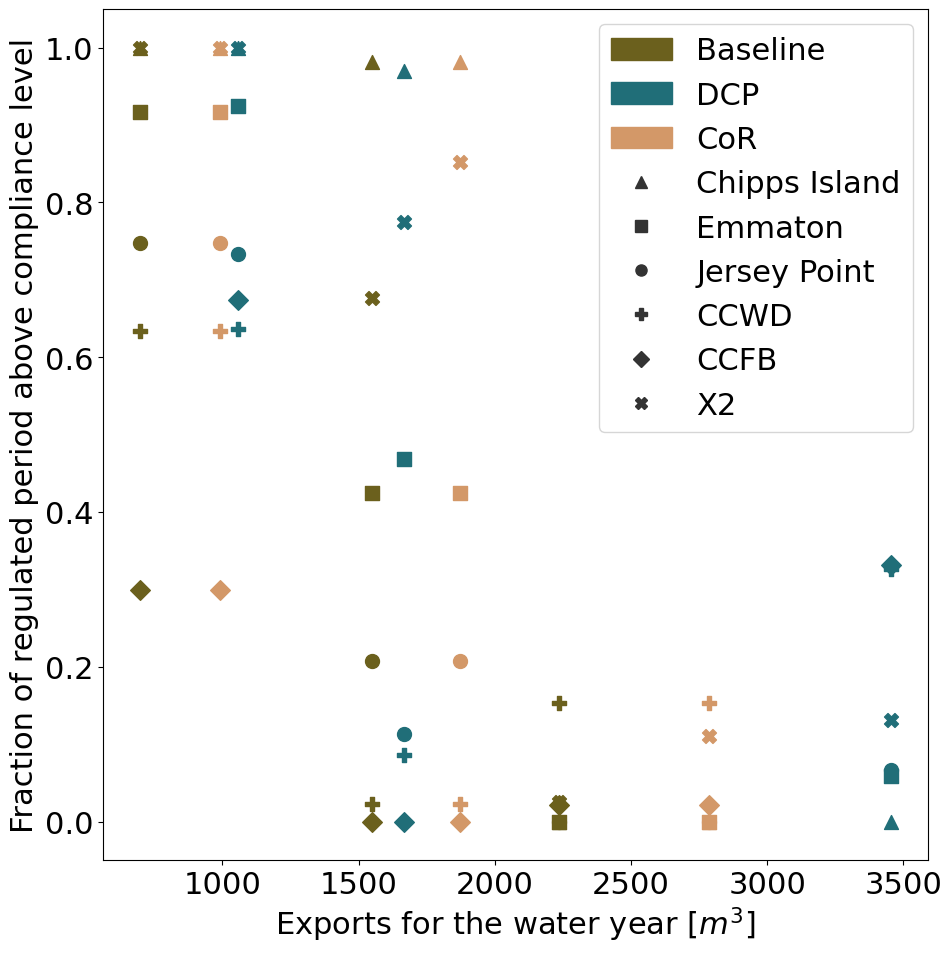

In [13]:
fig, ax = plt.subplots(figsize=(10,10),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
scs = np.arange(0,3) # the scenarios
stats = [0,1,2,4,5,6] # no station 3
syms = ["^","s","o","oo","P","D","X"]
cols = [cmocean.cm.tarn(1/6), cmocean.cm.tarn(10/12),cmocean.cm.tarn(2/6)]
for y in years:
    xdata = df_exports[ystr[y]]
    ydata = [df_compliance1_norm[ystr[y]],
             df_compliance2_norm[ystr[y]],
             df_compliance3_norm[ystr[y]]]
    # print(xdata)
    # print(ydata)
    #change color with scenario
    for sc in scs:
    # change marker with station
        for r in stats:
         ax.scatter(xdata[sc], ydata[sc][r], c = cols[sc], marker = syms[r],s = 100)


ax.set_xlabel(r'Exports for the water year [$m^3$]')
ax.set_ylabel('Fraction of regulated period above compliance level')
ax.set_ylim(-0.05,1.05)

# Make a patch legend
syms = ["^","s","o","P","D","X"]
symbol_labels = ["Chipps Island", "Emmaton", "Jersey Point", "CCWD", "CCFB", "X2"]

# 3. Build the Color Patches (Scenarios)
color_handles = [
    mpatches.Patch(color=cols[i], label=label) 
    for i, label in enumerate(scen)
]

# 4. Build the Symbol Lines (Locations)
# Single neutral color for the markers (e.g., #333333 dark gray)
symbol_handles = [
    mlines.Line2D([], [], color='none', marker=syms[i], 
                  markerfacecolor='#333333', markeredgecolor='#333333', 
                  markersize=8, label=label)
    for i, label in enumerate(symbol_labels)
]
# Combine handles into a structured legend layout
all_handles = color_handles + symbol_handles

ax.legend(
    handles=all_handles, 
    ncol=1,                     # 2 columns: Scenarios vs Locations
    loc='upper right', 
    #bbox_to_anchor=(0.5, -0.15) # Places it nicely below the chart area
)

plt.tight_layout()
plt.show()


plt.show()
#ax[s].set_xlim(0,11)
#ax[s].set_title(sta[idx])

# Repeat but with salinity days

/scratch/jisrael/job_54659335/ipykernel_970701/2838647829.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(xdata[sc], ydata[sc][r], c = cols[sc], marker = syms[r],s = 100)
/scratch/jisrael/job_54659335/ipykernel_970701/2838647829.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(xdata[sc], ydata1[sc][r], c = cols[sc], marker = syms[r],s = 100)
/scratch/jisrael/job_54659335/ipykernel_970701/

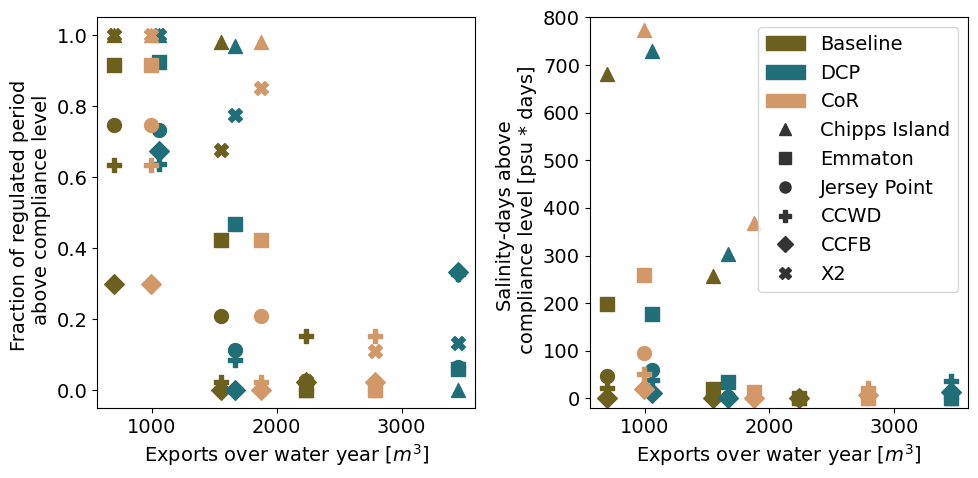

In [43]:
fig, ax = plt.subplots(ncols = 2, figsize=(10,5),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 14})
scs = np.arange(0,3) # the scenarios
stats = [0,1,2,4,5,6] # no station 3
syms = ["^","s","o","oo","P","D","X"]
cols = [cmocean.cm.tarn(1/6), cmocean.cm.tarn(10/12),cmocean.cm.tarn(2/6)]
for y in years:
    xdata = df_exports[ystr[y]]
    ydata = [df_compliance1_norm[ystr[y]],
             df_compliance2_norm[ystr[y]],
             df_compliance3_norm[ystr[y]]]
    ydata1 = [df_sd1[ystr[y]],
              df_sd2[ystr[y]],
              df_sd3[ystr[y]]]
    
    # print(xdata)
    # print(ydata)
    #change color with scenario
    for sc in scs:
    # change marker with station
        for r in stats:
            ax[0].scatter(xdata[sc], ydata[sc][r], c = cols[sc], marker = syms[r],s = 100)
            if r<6:
                ax[1].scatter(xdata[sc], ydata1[sc][r], c = cols[sc], marker = syms[r],s = 100)   

ax[0].set_xlabel(r'Exports over water year [$m^3$]')
ax[0].set_ylabel('Fraction of regulated period \n above compliance level')
ax[0].set_ylim(-0.05,1.05)

ax[1].set_xlabel(r'Exports over water year [$m^3$]')
ax[1].set_ylabel('Salinity-days above \n compliance level [psu * days]')
ax[1].set_ylim(-20,800)


# Make a patch legend
syms = ["^","s","o","P","D","X"]
symbol_labels = ["Chipps Island", "Emmaton", "Jersey Point", "CCWD", "CCFB", "X2"]

# 3. Build the Color Patches (Scenarios)
color_handles = [
    mpatches.Patch(color=cols[i], label=label) 
    for i, label in enumerate(scen)
]

# 4. Build the Symbol Lines (Locations)
# Single neutral color for the markers (e.g., #333333 dark gray)
symbol_handles = [
    mlines.Line2D([], [], color='none', marker=syms[i], 
                  markerfacecolor='#333333', markeredgecolor='#333333', 
                  markersize=8, label=label)
    for i, label in enumerate(symbol_labels)
]
# Combine handles into a structured legend layout
all_handles = color_handles + symbol_handles

ax[1].legend(
    handles=all_handles, 
    ncol=1,                     # 2 columns: Scenarios vs Locations
    loc='upper right', 
    #bbox_to_anchor=(0.5, -0.15) # Places it nicely below the chart area
)

plt.tight_layout()
plt.show()


plt.show()
#ax[s].set_xlim(0,11)
#ax[s].set_title(sta[idx])
fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3/figures/2026_10_04_compliance_salinitydays_exports.png')

            

# Annotate the top of the figure with the water year

/scratch/jisrael/job_54659335/ipykernel_970701/1358107522.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(xdata[sc], ydata[sc][r], c = cols[sc], marker = syms[r],s = 100)
/scratch/jisrael/job_54659335/ipykernel_970701/1358107522.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(xdata[sc], ydata1[sc][r], c = cols[sc], marker = syms[r],s = 100)
/scratch/jisrael/job_54659335/ipykernel_970701/

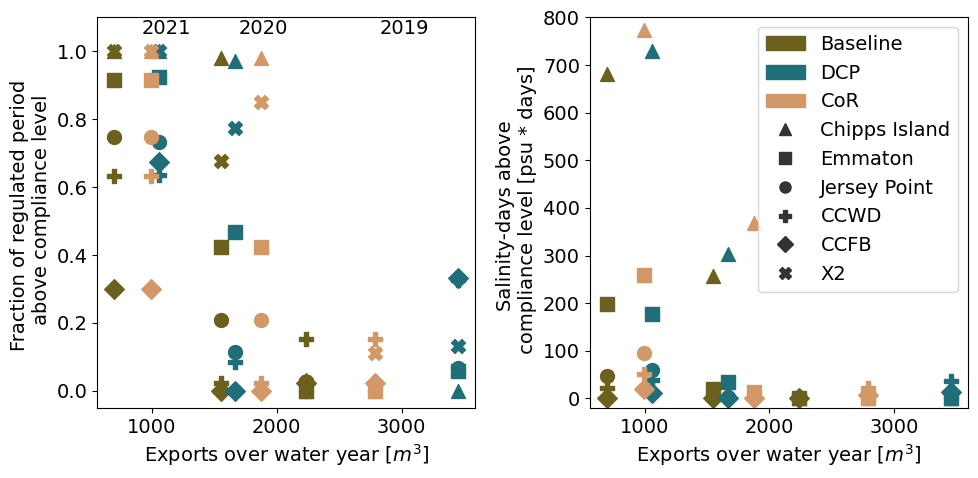

In [44]:
fig, ax = plt.subplots(ncols = 2, figsize=(10,5),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 14})
scs = np.arange(0,3) # the scenarios
stats = [0,1,2,4,5,6] # no station 3
syms = ["^","s","o","oo","P","D","X"]
cols = [cmocean.cm.tarn(1/6), cmocean.cm.tarn(10/12),cmocean.cm.tarn(2/6)]
for y in years:
    wy = ystr[y]
    xdata = df_exports[ystr[y]]
    ydata = [df_compliance1_norm[ystr[y]],
             df_compliance2_norm[ystr[y]],
             df_compliance3_norm[ystr[y]]]
    ydata1 = [df_sd1[ystr[y]],
              df_sd2[ystr[y]],
              df_sd3[ystr[y]]]
    
    # print(xdata)
    # print(ydata)
    #change color with scenario
    for sc in scs:
    # change marker with station
        for r in stats:
            ax[0].scatter(xdata[sc], ydata[sc][r], c = cols[sc], marker = syms[r],s = 100)
            #ax[0].annotate(wy, (xdata[sc], ydata[sc][r]))
            if r<6:
                ax[1].scatter(xdata[sc], ydata1[sc][r], c = cols[sc], marker = syms[r],s = 100)  
                #ax[1].annotate(wy, (xdata[sc], ydata1[sc][r]))

    ax[0].annotate(wy,(xdata[sc],ydata[sc][r]),xytext = (np.mean(xdata),1.05))
ax[0].set_xlabel(r'Exports over water year [$m^3$]')
ax[0].set_ylabel('Fraction of regulated period \n above compliance level')
ax[0].set_ylim(-0.05,1.1)

ax[1].set_xlabel(r'Exports over water year [$m^3$]')
ax[1].set_ylabel('Salinity-days above \n compliance level [psu * days]')
ax[1].set_ylim(-20,800)


# Make a patch legend
syms = ["^","s","o","P","D","X"]
symbol_labels = ["Chipps Island", "Emmaton", "Jersey Point", "CCWD", "CCFB", "X2"]

# 3. Build the Color Patches (Scenarios)
color_handles = [
    mpatches.Patch(color=cols[i], label=label) 
    for i, label in enumerate(scen)
]

# 4. Build the Symbol Lines (Locations)
# Single neutral color for the markers (e.g., #333333 dark gray)
symbol_handles = [
    mlines.Line2D([], [], color='none', marker=syms[i], 
                  markerfacecolor='#333333', markeredgecolor='#333333', 
                  markersize=8, label=label)
    for i, label in enumerate(symbol_labels)
]
# Combine handles into a structured legend layout
all_handles = color_handles + symbol_handles

ax[1].legend(
    handles=all_handles, 
    ncol=1,                     # 2 columns: Scenarios vs Locations
    loc='upper right', 
    #bbox_to_anchor=(0.5, -0.15) # Places it nicely below the chart area
)

plt.tight_layout()
plt.show()


plt.show()
#ax[s].set_xlim(0,11)
#ax[s].set_title(sta[idx])
fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3/figures/2026_10_04_compliance_salinitydays_exports_annotated.png')


In [18]:
ydata1

[0    680.473787
 1    197.726698
 2     47.608050
 4     21.165576
 5      1.257944
 Name: 2021, dtype: float64,
 0    729.435339
 1    177.249800
 2     58.674349
 4     38.407171
 5     11.834563
 Name: 2021, dtype: float64,
 0    773.312943
 1    259.176800
 2     94.739374
 4     51.809787
 5     19.570644
 Name: 2021, dtype: float64]

In [ ]:
fig, ax = plt.subplots(figsize=(15,15),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in np.arange(0,len(sta)):
    if idx>3:
        s=(int(np.floor((idx-1)/2)),(idx-1) % 2) 
    elif idx==3:
        idx=np.nan
        print('Skip Franks Tract')
    else:
        s=(int(np.floor(idx/2)),idx % 2)
    if ~np.isnan(idx):
        print(s)
        #for each scenario, plot the export fraction on the x axis and fraction of days above compliance on y 
        count=0
        #for computing the correlation coefficient, need to collect all the x and ys to pass to function
        x1=df_exports_norm.loc[0,:]
        y1=df_compliance1norm.loc[idx,:]
        # result1 = linregress(x1,y1)
        x2=df_exports_norm.loc[1,:]
        y2=df_compliance2norm.loc[idx,:]
        # result2 = linregress(x2,y2)
        x3=df_exports_norm.loc[2,:]
        y3=df_compliance3norm.loc[idx,:]
        # result3 = linregress(x3,y3)
        # minx=np.min(x1)
        # maxy=np.max(y1)
        col=cmocean.cm.tarn(1/6)
        ax[s].scatter(x1,y1,color=col,label=scen[0],s=180)
        #try kruskal wallis test for the compliance 
        result=kruskal(y1,y2,y3)
        print(result.pvalue)
        ax[s].annotate('KW p {:.3f}'.format(result.pvalue),(7.6,0.9))
        #ax[s].annotate("B m = {:.3f} ({:.2f})".format(result1.slope,result1.rvalue), (minx,maxy*0.95))
        # ax[s].xlim(minx-0.05*np.max(x),1.05*np.max(x))
        # ax[s].ylim(np.min(y)-0.05*np.max(y),1.15*maxy)
        col=cmocean.cm.tarn(10/12)
        ax[s].scatter(x2,y2,color=col,label=scen[1],marker='^',s=180)
        #ax[s].annotate("DCP m = {:.3f} ({:.2f})".format(result2.slope,result2.rvalue), (minx,maxy*0.90))
        col=cmocean.cm.tarn(2/6)
        ax[s].scatter(x3,y3,color=col,label=scen[2],marker='+',s=180)
        #ax[s].annotate("CoR m = {:.3f} ({:.2f})".format(result3.slope,result3.rvalue), (minx,maxy*0.85))
        if idx==0 and count==0:
            ax[s].legend()#frameon=False)
            count=count+1
            
        ax[s].set_xlabel(r'Exports [$m^3$]')
        ax[s].set_ylabel('Days above compliance level')
        ax[s].set_ylim(-0.05,1.05)
        ax[s].set_xlim(0,11)
        ax[s].set_title(sta[idx])
plt.show()        
        
# ax[1,0].set_ylabel('Fraction of month above compliance')
# ax[1,1].set_ylabel('Fraction of month above compliance')
#fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3/figures/2026_08_25_compliance_exports_correlation_kruskalwallis_3yr.png')

In [ ]:
# #divide each column by the number of days in the month
# df_compliance1norm=df_compliance1.copy()/31
# df_compliance2norm=df_compliance2.copy()/31
# df_compliance3norm=df_compliance3.copy()/31

# #now correct the months that dont have 30 days
# for c in df_compliance1norm.columns:
#     #if c in ['4','6','9','11']:
#     # this is not going to work anymore bc column order is chronological months since Oct 2018
#     if morder[int(c)] in  [4,6,9,11]:
#         print('30 days have september, april, june, and november index '+str(c))
#         #months w/ 30 days
#         df_compliance1norm[c]=df_compliance1norm[c]*31/30
#         df_compliance2norm[c]=df_compliance2norm[c]*31/30
#         df_compliance3norm[c]=df_compliance3norm[c]*31/30
#     #need to account for 2020 being a leap year
#     elif c in ['4','28']:
#         print('nonleap feb is index ' +str(c))
#         df_compliance1norm[c]=df_compliance1norm[c]*31/28 #assumes not a leap year
#         df_compliance2norm[c]=df_compliance2norm[c]*31/28
#         df_compliance3norm[c]=df_compliance3norm[c]*31/28
#     elif c=='16':
#         print('leap feb is index ' +str(c))
#         df_compliance1norm[c]=df_compliance1norm[c]*31/29 #assumes not a leap year
#         df_compliance2norm[c]=df_compliance2norm[c]*31/29
#         df_compliance3norm[c]=df_compliance3norm[c]*31/29
# df_compliance1norm
